In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

In [2]:
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
})

In [3]:
# --- Exercise 1: Newton Method Implementation ---
# Function newton(F, dF, x0, delta, epsilon, maxIter)
def newton(F, dF, x0, delta=1e-4, epsilon=1e-4, maxIter=100):
    """
    Implements the Newton method for finding roots of F(x) = 0.
    
    Parameters:
    F:       Function returning the value (scalar or vector).
    dF:      Function returning the derivative (scalar) or Jacobian (matrix).
    x0:      Start value (scalar or vector).
    delta:   Step size tolerance for stopping.
    epsilon: Function value tolerance for stopping.
    maxIter: Maximum number of iterations.
    
    Returns:
    x:       The approximate root.
    k:       Number of iterations performed (useful for convergence plots).
    """
    x = np.array(x0, dtype=float) if not np.iscomplexobj(x0) else np.array(x0)
    
    # Check if we are dealing with a system (vector) or scalar/complex 1D
    is_scalar = x.shape == ()
    
    for k in range(maxIter):
        val = F(x)
        
        # Check residual convergence [cite: 8]
        if np.linalg.norm(val) < epsilon:
            return x
            
        jac = dF(x)
        
        # Newton Step: Solve J * s = -F(x)  =>  x_new = x + s
        if is_scalar:
            # 1D case (works for real and complex scalars)
            step = val / jac
        else:
            # Multidimensional case: solve linear system
            step = np.linalg.solve(jac, val)
        
        x_new = x - step
        
        # Check step size convergence [cite: 8]
        if np.linalg.norm(x_new - x) < delta:
            return x_new
            
        x = x_new
        
    return x

In [4]:
# --- Exercise 2: 1D Root Finding ---
# Function f(x) = x^3 - 2x 
def ex2_f(x): return x**3 - 2*x
def ex2_df(x): return 3*x**2 - 2

print("--- Exercise 2 ---")
start_values = [0.1, 2, -2]
roots = []
for x0 in start_values:
    # Tolerances delta=epsilon=10^-10, max 50 iters 
    root = newton(ex2_f, ex2_df, x0, 1e-10, 1e-10, 50)
    roots.append(root)
    print(f"Start: {x0}, Root: {root:.6f}")

--- Exercise 2 ---
Start: 0.1, Root: 0.000000
Start: 2, Root: 1.414214
Start: -2, Root: -1.414214


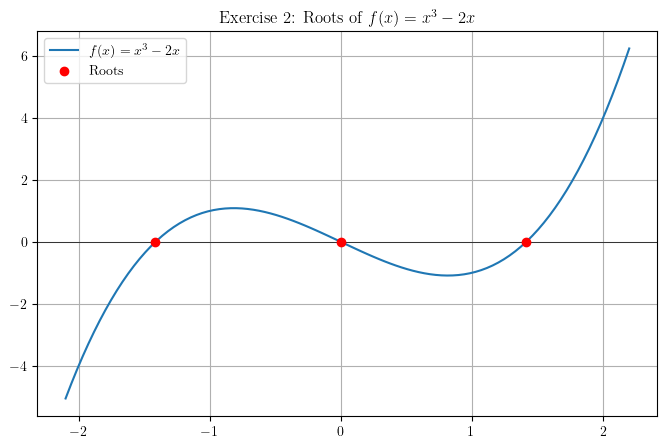

In [5]:
# Plotting for Exercise 2
x_plot = np.linspace(-2.1, 2.2, 100)
p2 = plt.figure(figsize=(8, 5))
plt.plot(x_plot, ex2_f(x_plot), label='$f(x) = x^3 - 2x$')
plt.axhline(0, color='black', linewidth=0.5)
plt.scatter(roots, ex2_f(np.array(roots)), color='red', zorder=5, label='Roots')
plt.title('Exercise 2: Roots of $f(x) = x^3 - 2x$')
plt.legend()
plt.grid(True)
plt.savefig("ex_2.pdf", dpi=100)
plt.show()

In [6]:
# --- Exercise 3: 2D System of Equations ---
# F(x) vector definition 
def ex3_F(x):
    x1, x2 = x[0], x[1]
    return np.array([
        x1**2 + x2**2 - 6*x1,
        0.75 * np.exp(-x1) - x2
    ])

# Jacobian definition
def ex3_dF(x):
    x1, x2 = x[0], x[1]
    # Row 1: d/dx1, d/dx2 of first eq
    # Row 2: d/dx1, d/dx2 of second eq
    return np.array([
        [2*x1 - 6,       2*x2],
        [-0.75 * np.exp(-x1), -1]
    ])

print("\n--- Exercise 3 ---")
x0_ex3 = [0.08, 0.7]
res_ex3 = newton(ex3_F, ex3_dF, x0_ex3)
print(f"Root found at: {res_ex3}") 


--- Exercise 3 ---
Root found at: [0.08083301 0.69176054]



--- Exercise 4: Generating Fractal ---


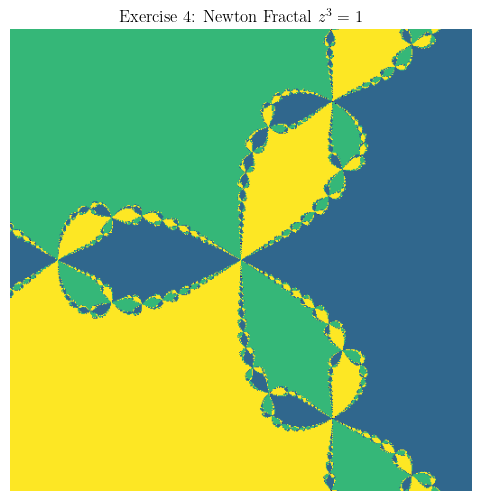

In [7]:
# --- Exercise 4: Complex Newton (z^3 = 1) ---
# Equation z^3 - 1 = 0 
# While the 'newton' function above is generic, calculating it pixel-by-pixel 
# in Python loops is slow. We use a vectorized approach logic here 
# that mirrors the Newton steps for the grid.

print("\n--- Exercise 4: Generating Fractal ---")
def newton_fractal_z3(width=512, max_iter=15, tol=1e-5):
    # Discretize Box B_inf
    x = np.linspace(-1, 1, width)
    y = np.linspace(-1, 1, width)
    X, Y = np.meshgrid(x, y)
    Z = X + 1j * Y
    
    # Newton iteration: z_new = z - (z^3 - 1) / (3z^2)
    # This is z_new = z - (z/3) + (1/(3z^2)) = (2/3)z + 1/(3z^2)
    
    active_mask = np.ones(Z.shape, dtype=bool)
    
    for i in range(max_iter):
        # Avoid division by zero
        Z_active = Z[active_mask]
        with np.errstate(divide='ignore', invalid='ignore'):
            # Standard Newton Step
            f_val = Z_active**3 - 1
            df_val = 3 * Z_active**2
            step = f_val / df_val
            
            Z_new = Z_active - step
            
            # Check convergence
            diff = np.abs(step)
            # Mark converged points (stop updating them)
            # Using delta=epsilon=10^-5 logic combined
            converged = (diff < tol) | (np.abs(Z_new**3 - 1) < tol)
            
            # Update the main grid
            Z[active_mask] = Z_new
            
            # Update mask (only keep non-converged active)
            # We map the subset back to the full mask is complex, 
            # simplest is just to update all and check convergence at end for coloring
            # or update in place. For clarity/speed in python:
            Z = Z - (Z**3 - 1)/(3*Z**2 + 1e-16)

    return Z

Z_res_4 = newton_fractal_z3(max_iter=15, tol=1e-5)

# Identify roots to color [cite: 21]
# Roots of z^3=1 are 1, -0.5+0.866j, -0.5-0.866j
roots_z3 = np.array([1, -0.5 + 0.866j, -0.5 - 0.866j])
colors = np.zeros(Z_res_4.shape)

for i, r in enumerate(roots_z3):
    # Determine which pixels are close to which root
    mask = np.abs(Z_res_4 - r) < 0.1
    colors[mask] = i + 1

plt.figure(figsize=(6, 6))
plt.imshow(colors, extent=[-1, 1, -1, 1], origin='lower')
plt.title('Exercise 4: Newton Fractal $z^3=1$')
plt.axis('off')
plt.savefig("ex_4.pdf", dpi=100)
plt.show()


--- Exercise 5: Generating Phase Fractals ---


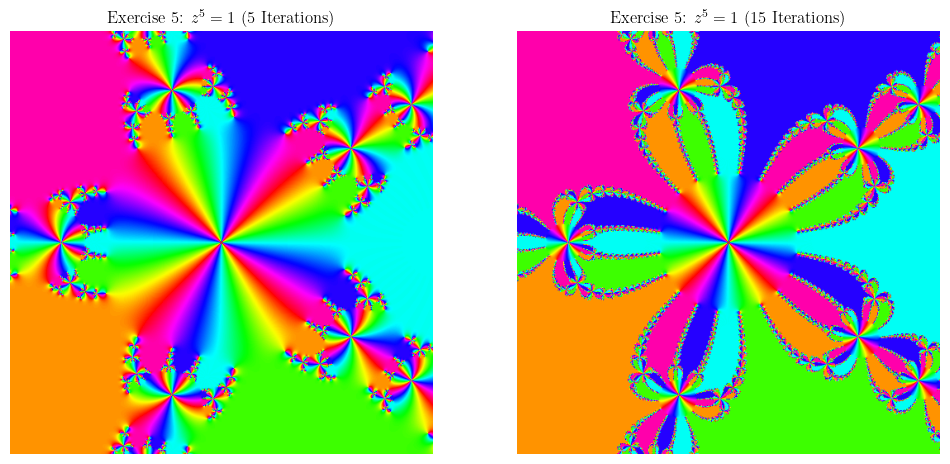

In [8]:
# --- Exercise 5: Complex Newton (z^5 = 1) Phase Coloring ---
# [cite: 26, 27]
print("\n--- Exercise 5: Generating Phase Fractals ---")

def newton_fractal_z5(max_iter):
    # Grid setup same as Ex 4 [cite: 28]
    width = 512
    x = np.linspace(-1, 1, width)
    y = np.linspace(-1, 1, width)
    X, Y = np.meshgrid(x, y)
    Z = X + 1j * Y
    
    for i in range(max_iter):
        # z_new = z - (z^5 - 1)/(5z^4)
        # z_new = (4/5)z + 1/(5z^4)
        with np.errstate(divide='ignore', invalid='ignore'):
             Z = 0.8 * Z + 1.0 / (5.0 * Z**4 + 1e-16)
    return Z

# Run 1: 5 Iterations [cite: 28]
Z_res_5a = newton_fractal_z5(max_iter=5)
phase_5a = np.angle(Z_res_5a) # Phase for coloring [cite: 29]

# Run 2: 15 Iterations [cite: 28]
Z_res_5b = newton_fractal_z5(max_iter=15)
phase_5b = np.angle(Z_res_5b)

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(phase_5a, extent=[-1, 1, -1, 1], cmap='hsv', origin='lower')
ax[0].set_title('Exercise 5: $z^5=1$ (5 Iterations)')
ax[0].axis('off')

ax[1].imshow(phase_5b, extent=[-1, 1, -1, 1], cmap='hsv', origin='lower')
ax[1].set_title('Exercise 5: $z^5=1$ (15 Iterations)')
ax[1].axis('off')
plt.savefig("ex_5.pdf", dpi=100)
plt.show()

In [9]:
# --- Exercise 6: Minimization ---
# Function: (x1+1)^2 + (x2-1)^4 (Interpreted from OCR) 
# To minimize f(x), we find root of gradient (nabla f = 0).
# Newton for opt: x_new = x - H^-1 * grad(f)

def ex6_Grad(x):
    x1, x2 = x[0], x[1]
    return np.array([
        2 * (x1 + 1),
        4 * (x2 - 1)**3
    ])

def ex6_Hessian(x):
    x1, x2 = x[0], x[1]
    return np.array([
        [2, 0],
        [0, 12 * (x2 - 1)**2]
    ])

print("\n--- Exercise 6 ---")
x0_ex6 = np.array([-1.1, 1.1]) 
# We use the generic newton function defined in Ex 1
# But we pass Gradient as 'F' and Hessian as 'dF'
res_ex6 = newton(ex6_Grad, ex6_Hessian, x0_ex6)
print(f"Minimum found at: {res_ex6}")


--- Exercise 6 ---
Minimum found at: [-1.          1.01975309]



--- Exercise 7: Mandelbrot Iteration ---


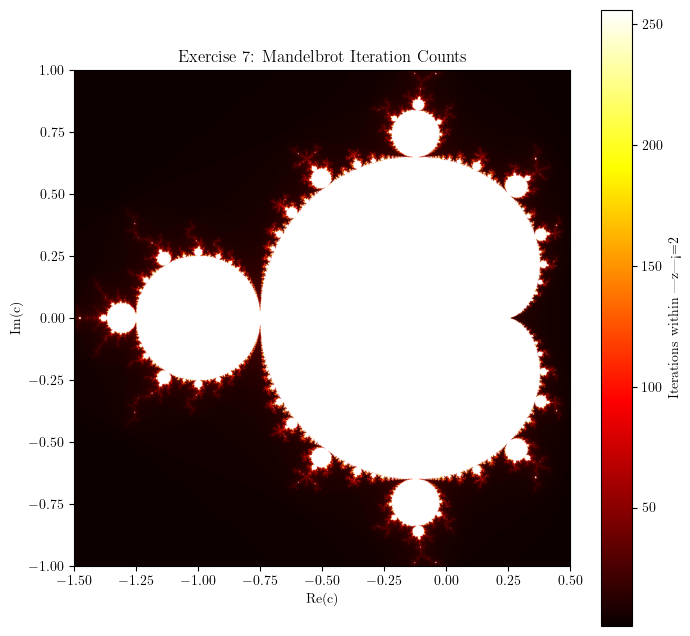

In [10]:
# --- Exercise 7: Mandelbrot Set ---
print("\n--- Exercise 7: Mandelbrot Iteration ---")
# Grid M: x [-1.5, 0.5], y [-1, 1], 1024 points [cite: 36]
def mandelbrot_iter(width=1024, max_iter=256):
    x = np.linspace(-1.5, 0.5, width)
    y = np.linspace(-1, 1, width)
    X, Y = np.meshgrid(x, y)
    C = X + 1j * Y
    Z = C.copy() # Start value z0 = c
    
    # We need to count iterations where |z| <= 2 [cite: 38]
    # Initialize count array
    count = np.zeros(C.shape, dtype=int)
    
    # Create a mask for points that haven't escaped yet
    active = np.ones(C.shape, dtype=bool)
    
    for i in range(max_iter):
        if not np.any(active):
            break
            
        # z = z^2 + c
        Z[active] = Z[active]**2 + C[active]
        
        # Check escape condition |z| > 2
        escaped = np.abs(Z) > 2
        
        # For points that are currently active and just escaped:
        # Their count is the current iteration index i (approx)
        # However, the problem asks for "Number of iterates with |z| <= 2".
        # If it never escapes, count is max_iter.
        # If it escapes at step i, it had i valid steps.
        
        # Update active mask: turn off escaped points
        # But first update counts for those that are still active
        count[active] += 1
        
        # Now mark escaped as inactive
        active[escaped] = False

    return count

mandel_counts = mandelbrot_iter()

plt.figure(figsize=(8, 8))
# Visualizing the count 
plt.imshow(mandel_counts, extent=[-1.5, 0.5, -1, 1], cmap='hot', origin='lower')
plt.title('Exercise 7: Mandelbrot Iteration Counts')
plt.xlabel('Re(c)')
plt.ylabel('Im(c)')
plt.colorbar(label='Iterations within |z|<=2')
plt.savefig("ex_7.pdf", dpi=100)
plt.show()